In [3]:
!pip install ucimlrepo pandas numpy matplotlib scikit-learn

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo

In [5]:
dataset = fetch_ucirepo(id=572)

X = dataset.data.features.copy()
y = dataset.data.targets.copy()

if isinstance(y, pd.DataFrame):
    y = y.iloc[:, 0]

df = X.copy()
df["Bankrupt?"] = y

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [6]:
print("Shape:", df.shape)

print("\nFirst 5 rows:")
print(df.head())

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values per column:")
print(df.isnull().sum())

print("\nTotal missing values:", df.isnull().sum().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nTarget distribution:")
print(df["Bankrupt?"].value_counts())

print("\nTarget distribution (%):")
print(df["Bankrupt?"].value_counts(normalize=True) * 100)

print("\nSummary statistics:")
print(df.describe())

print("\nInfinite values:")
print(np.isinf(df.select_dtypes(include=[np.number])).sum().sum())

print("\nNon-numeric columns:")
print(df.drop(columns=["Bankrupt?"]).select_dtypes(exclude=[np.number]).columns.tolist())

Shape: (6819, 96)

First 5 rows:
    ROA(C) before interest and depreciation before interest  \
0                                           0.370594          
1                                           0.464291          
2                                           0.426071          
3                                           0.399844          
4                                           0.465022          

    ROA(A) before interest and % after tax  \
0                                 0.424389   
1                                 0.538214   
2                                 0.499019   
3                                 0.451265   
4                                 0.538432   

    ROA(B) before interest and depreciation after tax  \
0                                           0.405750    
1                                           0.516730    
2                                           0.472295    
3                                           0.457733    
4                         

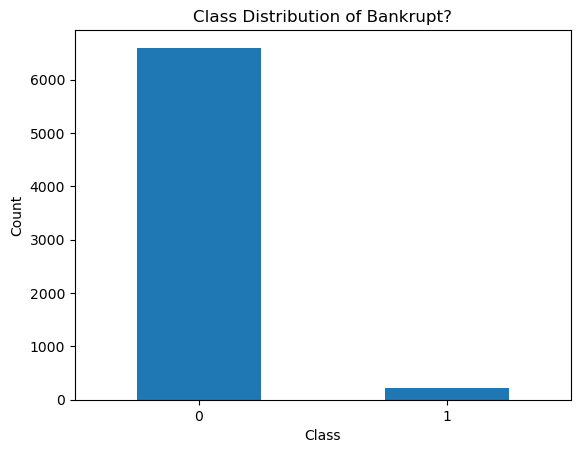

In [7]:
df["Bankrupt?"].value_counts().plot(kind="bar")
plt.title("Class Distribution of Bankrupt?")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [8]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Bankrupt?"])
y = df["Bankrupt?"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train distribution:")
print(y_train.value_counts())
print("y_test distribution:")
print(y_test.value_counts())

X_train shape: (5455, 95)
X_test shape: (1364, 95)
y_train distribution:
Bankrupt?
0    5279
1     176
Name: count, dtype: int64
y_test distribution:
Bankrupt?
0    1320
1      44
Name: count, dtype: int64


In [9]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [10]:
y_pred = rf_model.predict(X_test)

print("Predictions completed.")

Predictions completed.


In [11]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="weighted", zero_division=0))
print("Recall:", recall_score(y_test, y_pred, average="weighted", zero_division=0))
print("F1-score:", f1_score(y_test, y_pred, average="weighted", zero_division=0))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.9721407624633431
Precision: 0.9668829929375835
Recall: 0.9721407624633431
F1-score: 0.9643478020916691
Balanced Accuracy: 0.6011363636363636

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99      1320
           1       0.75      0.20      0.32        44

    accuracy                           0.97      1364
   macro avg       0.86      0.60      0.65      1364
weighted avg       0.97      0.97      0.96      1364



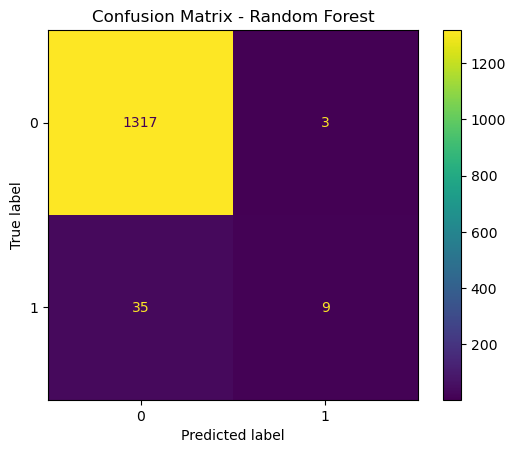

In [12]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Random Forest")
plt.show()

In [13]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(feature_importance.head(15))

                                              Feature  Importance
39                               Borrowing dependency    0.043412
18            Persistent EPS in the Last Four Seasons    0.043348
85                         Net Income to Total Assets    0.041668
35                         Total debt/Total net worth    0.041256
9                Continuous interest rate (after tax)    0.040335
37                                   Net worth/Assets    0.033906
36                                       Debt ratio %    0.032248
94                                Equity to Liability    0.032125
67                  Retained Earnings to Total Assets    0.030090
68                         Total income/Total expense    0.029445
42              Net profit before tax/Paid-in capital    0.026315
7                         After-tax net Interest Rate    0.026281
90                                Liability to Equity    0.023559
2    ROA(B) before interest and depreciation after...    0.020839
33        

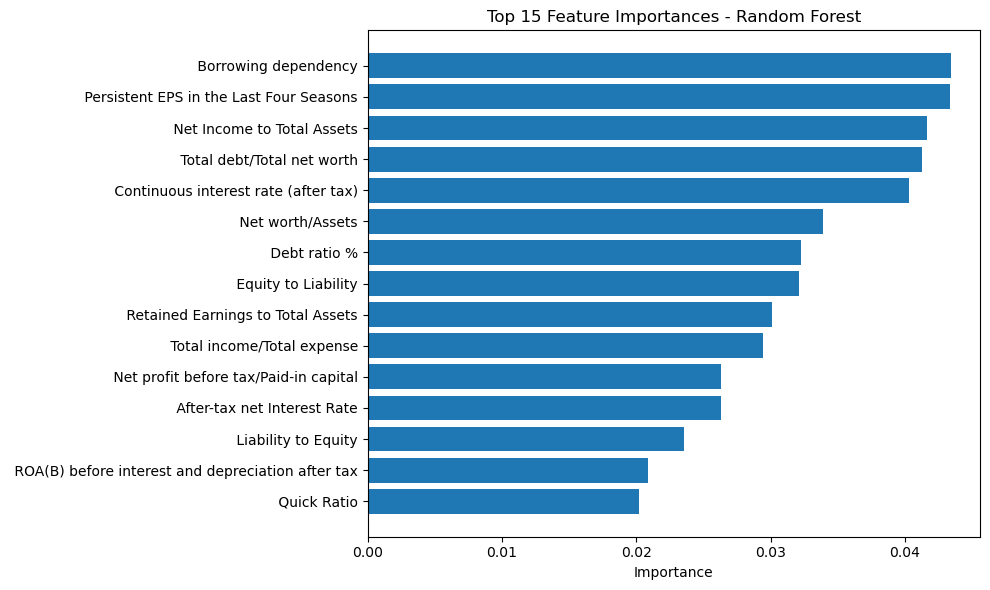

In [14]:
top15 = feature_importance.head(15).sort_values(by="Importance")
plt.figure(figsize=(10, 6))
plt.barh(top15["Feature"], top15["Importance"])
plt.xlabel("Importance")
plt.title("Top 15 Feature Importances - Random Forest")
plt.tight_layout()
plt.show()